# Task 3 – Conversion KPIs and customers

**For:** the marketing team and the product owners of the verticals.

**The tables**, built and tested in dbt (`dbt/models/marts/`):
- `mart_lead_conversions_monthly`: one row per vertical, channel and lead month, with leads, conversions, the
  conversion rate and the contracts by status.
- `mart_customers`: one row per customer, with leads, contracts, active premium and whether the customer holds
  an active contract today.

Both are built from `mart_lead_conversions` (Task 2), so they use the same definitions. This notebook shows
sample queries and charts on them.

**Before running:** `cd dbt && dbt build` creates the database file `dbt/lead_conversions.duckdb`.

### Definitions

- **Conversion:** a lead that led to a signed contract, whatever its current status (active, cancelled or
  pending). A later cancellation does not undo the conversion.
- **Month:** the month the lead came in. A conversion counts in the month of its lead, even if the contract was
  signed later, so a conversion rate never exceeds 100 %.
- **Complete month (`is_complete`):** contracts are signed up to 40 days after the lead. A month counts as
  complete once all of its leads are at least 40 days old on the last day of the data (2024-11-29); until then,
  its conversion rate can still grow. October 2024 is not complete yet.
- **Contract status:** today's status of each contract (active, pending or cancelled). The data has no status
  history, so when a contract is cancelled later, the numbers of its lead month change.
- **Customer:** a person, identified by the e-mail address. Two addresses count as two customers, even with the
  same name.
- **The customer view counts all contracts of a person**, including the 9 whose lead is unknown. They are
  missing from the lead tables, because they cannot be credited to a lead, but they belong to the person.
- **Combining rows:** for a rate over several rows (e.g. all months of a channel), add up leads and conversions
  and divide again. Averaging the rates would give a month with 6 leads the same weight as one with 20.

`mart_lead_conversions_monthly`

| column | meaning |
|---|---|
| `vertical`, `source` | comparison calculator and marketing channel (`unknown` if missing or contradictory) |
| `lead_month` | first day of the month the leads came in |
| `leads` | number of leads |
| `conversions` | number of these leads with a signed contract |
| `conversion_rate` | conversions / leads, between 0 and 1 |
| `active_contracts`, `pending_contracts`, `cancelled_contracts` | the conversions by the contract's status today |
| `is_complete` | false while the leads of the month can still convert |

`mart_customers`

| column | meaning |
|---|---|
| `customer_email` | e-mail address of the customer |
| `leads` | number of leads of the customer |
| `conversions` | number of signed contracts, whatever their status |
| `total_active_premium` | annual net premium of the active contracts in EUR (empty if a premium is missing) |
| `has_active_contract` | true if the customer holds an active contract today |

In [1]:
import plotly.express as px

# Shared by the notebooks, see notebooks/common/
from common import bar_chart, configure_plotly, query

configure_plotly()

## Part 1: Conversion KPIs (`mart_lead_conversions_monthly`)

### 1. The table at a glance

In [2]:
query("""
    select *
    from mart_lead_conversions_monthly
    order by lead_month, vertical, source
    limit 8
""")

,vertical,source,lead_month,leads,conversions,conversion_rate,active_contracts,pending_contracts,cancelled_contracts,is_complete
0,auto,direct,2024-01-01,1,0,0.0,0,0,0,True
1,auto,google,2024-01-01,2,2,1.0,1,0,1,True
2,auto,newsletter,2024-01-01,1,1,1.0,0,0,1,True
3,haushalt,newsletter,2024-01-01,1,0,0.0,0,0,0,True
4,leben,google,2024-01-01,1,0,0.0,0,0,0,True
5,auto,direct,2024-02-01,1,0,0.0,0,0,0,True
6,auto,newsletter,2024-02-01,2,1,0.5,1,0,0,True
7,haushalt,direct,2024-02-01,1,0,0.0,0,0,0,True


**Reading:** one row per vertical, channel and month, so a single row holds only a few leads (1 or 2 in the
sample above). The questions below therefore add rows up.

### 2. Which channel converts best?

In [3]:
channels = query("""
    select
        source as channel,
        sum(leads) as leads,
        sum(conversions) as conversions,
        round(100.0 * sum(conversions) / sum(leads), 1) as conversion_rate_pct
    from mart_lead_conversions_monthly
    group by source
    order by conversion_rate_pct desc, channel
""")
channels

,channel,leads,conversions,conversion_rate_pct
0,unknown,2,1,50.0
1,newsletter,41,16,39.0
2,google,36,12,33.3
3,direct,40,12,30.0


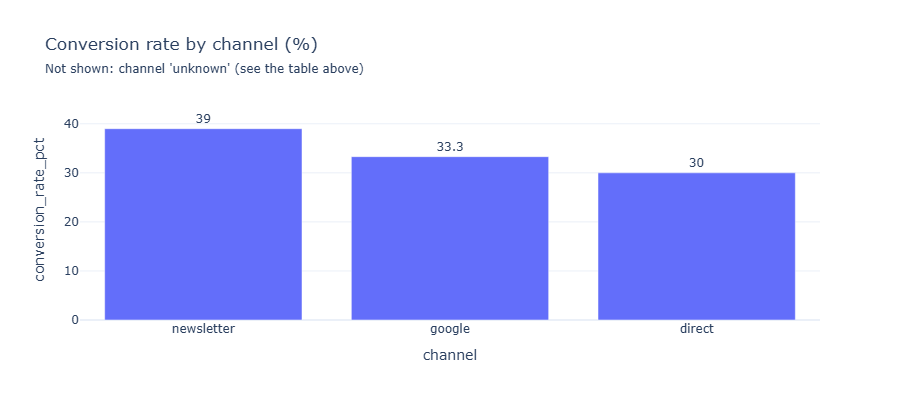

In [4]:
bar_chart(channels, x="channel", y="conversion_rate_pct", title="Conversion rate by channel (%)")

**Reading:** newsletter leads convert best (39.0 %), direct leads least (30.0 %). The numbers are small, though:
with 36–41 leads per channel, the gap between newsletter and direct is about 4 leads. The rate is calculated
from the summed leads and conversions, not averaged over the months.

### 3. Which vertical converts best?

In [5]:
verticals = query("""
    select
        vertical,
        sum(leads) as leads,
        sum(conversions) as conversions,
        round(100.0 * sum(conversions) / sum(leads), 1) as conversion_rate_pct
    from mart_lead_conversions_monthly
    group by vertical
    order by conversion_rate_pct desc, vertical
""")
verticals

,vertical,leads,conversions,conversion_rate_pct
0,unknown,2,1,50.0
1,haushalt,41,15,36.6
2,auto,32,11,34.4
3,leben,44,14,31.8


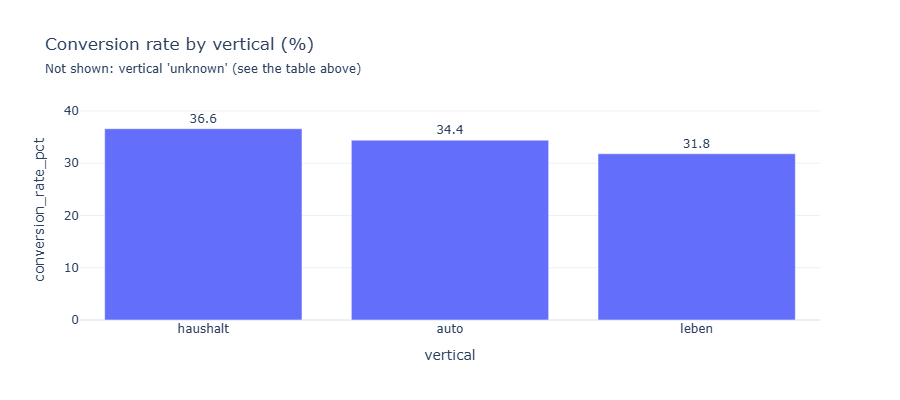

In [6]:
bar_chart(verticals, x="vertical", y="conversion_rate_pct", title="Conversion rate by vertical (%)")

**Reading:** haushalt converts best (36.6 %), leben least (31.8 %), a gap of about 2 leads.

### 4. How does the conversion rate develop over time?

In [7]:
monthly = query("""
    select
        lead_month,
        case when is_complete then 'complete' else 'can still grow' end as month_status,
        sum(leads) as leads,
        sum(conversions) as conversions,
        round(100.0 * sum(conversions) / sum(leads), 1) as conversion_rate_pct
    from mart_lead_conversions_monthly
    group by lead_month, is_complete
    order by lead_month
""")
monthly

,lead_month,month_status,leads,conversions,conversion_rate_pct
0,2024-01-01,complete,6,3,50.0
1,2024-02-01,complete,11,3,27.3
2,2024-03-01,complete,10,5,50.0
3,2024-04-01,complete,15,5,33.3
4,2024-05-01,complete,16,7,43.8
5,2024-06-01,complete,14,5,35.7
6,2024-07-01,complete,10,3,30.0
7,2024-08-01,complete,11,3,27.3
8,2024-09-01,complete,6,2,33.3
9,2024-10-01,can still grow,20,5,25.0


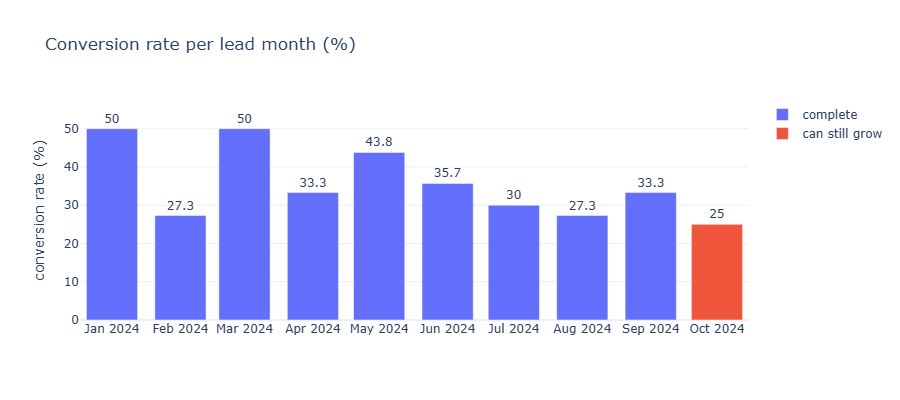

In [8]:
fig = px.bar(
    monthly,
    x="lead_month",
    y="conversion_rate_pct",
    color="month_status",
    text_auto=True,
    title="Conversion rate per lead month (%)",
    labels={"lead_month": "", "conversion_rate_pct": "conversion rate (%)", "month_status": ""},
)
fig.update_traces(textposition="outside")
fig.update_xaxes(dtick="M1", tickformat="%b %Y")
fig.update_yaxes(range=[0, monthly["conversion_rate_pct"].max() * 1.15])
fig.show()

**Reading:** October 2024 has the most leads (20) and the lowest conversion rate (25.0 %), but it is not
complete yet: its leads can still convert. The complete months vary between 27.3 % and 50.0 % with 6–16 leads
each, so a single month should not be over-interpreted.

### 5. Which channel brings contracts that last?

A conversion rate only says how many leads signed. What becomes of 100 leads per channel, including whether
their contracts are still active today:

In [9]:
per_100_leads = query("""
    select
        source as channel,
        sum(leads) as leads,
        round(100.0 * sum(active_contracts) / sum(leads), 1) as active,
        round(100.0 * sum(pending_contracts) / sum(leads), 1) as pending,
        round(100.0 * sum(cancelled_contracts) / sum(leads), 1) as cancelled,
        round(100.0 * (sum(leads) - sum(conversions)) / sum(leads), 1) as not_converted
    from mart_lead_conversions_monthly
    group by source
    order by active desc, channel
""")
per_100_leads

,channel,leads,active,pending,cancelled,not_converted
0,newsletter,41,31.7,0.0,7.3,61.0
1,direct,40,22.5,0.0,7.5,70.0
2,google,36,11.1,5.6,16.7,66.7
3,unknown,2,0.0,0.0,50.0,50.0


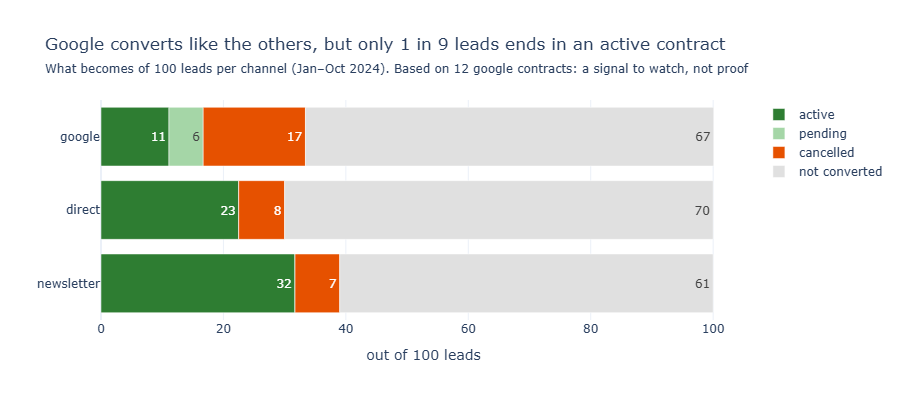

In [10]:
known = per_100_leads[per_100_leads["channel"] != "unknown"]
outcomes = known.melt(
    id_vars="channel",
    value_vars=["active", "pending", "cancelled", "not_converted"],
    var_name="outcome",
    value_name="per_100_leads",
)
outcomes["outcome"] = outcomes["outcome"].str.replace("_", " ")

fig = px.bar(
    outcomes,
    x="per_100_leads",
    y="channel",
    color="outcome",
    orientation="h",
    text_auto=".0f",
    category_orders={"channel": list(known["channel"])},
    color_discrete_map={
        "active": "#2e7d32",
        "pending": "#a5d6a7",
        "cancelled": "#e65100",
        "not converted": "#e0e0e0",
    },
    title="Google converts like the others, but only 1 in 9 leads ends in an active contract",
    labels={"per_100_leads": "out of 100 leads", "channel": "", "outcome": ""},
)
fig.update_layout(
    title_subtitle_text=(
        "What becomes of 100 leads per channel (Jan–Oct 2024). Based on 12 google contracts: "
        "a signal to watch, not proof"
    ),
    margin_t=100,
)
fig.update_yaxes(autorange="reversed")
fig.show()

**Reading:** out of 100 leads, newsletter ends in 32 active contracts, direct in 23, google in only 11, although
google converts about as often as the others (33 of 100 leads against 30 to 39). Half of the google contracts
(17 of the 33 per 100 leads) have already been cancelled. The numbers are small, and the status is today's: when
a contract was cancelled is not in the data. Still, the conversion rate alone would hide this: judged by lasting
contracts, google is the weakest channel.

## Part 2: Customers (`mart_customers`)

### 6. Customers at a glance

In [11]:
query("""
    select
        count(*) as customers,
        count_if(has_active_contract) as with_active_contract,
        count_if(leads > 1) as with_several_leads,
        count_if(conversions > 1) as with_several_contracts,
        sum(total_active_premium) as total_active_premium
    from mart_customers
""")

,customers,with_active_contract,with_several_leads,with_several_contracts,total_active_premium
0,88,24,21,7,17438.69


**Reading:** 88 customers, 24 of whom hold an active contract today, with 17,438.69 EUR of annual net premium
in total. 21 customers used a calculator more than once, and 7 have more than one contract.

### 7. Do customers who compare more often also sign more often?

In [12]:
by_leads = query("""
    select
        leads as leads_per_customer,
        count(*) as customers,
        count_if(conversions > 0) as with_contract,
        round(100.0 * count_if(conversions > 0) / count(*), 1) as with_contract_pct
    from mart_customers
    group by leads
    order by leads
""")
by_leads

,leads_per_customer,customers,with_contract,with_contract_pct
0,1,67,26,38.8
1,2,12,7,58.3
2,3,8,7,87.5
3,4,1,1,100.0


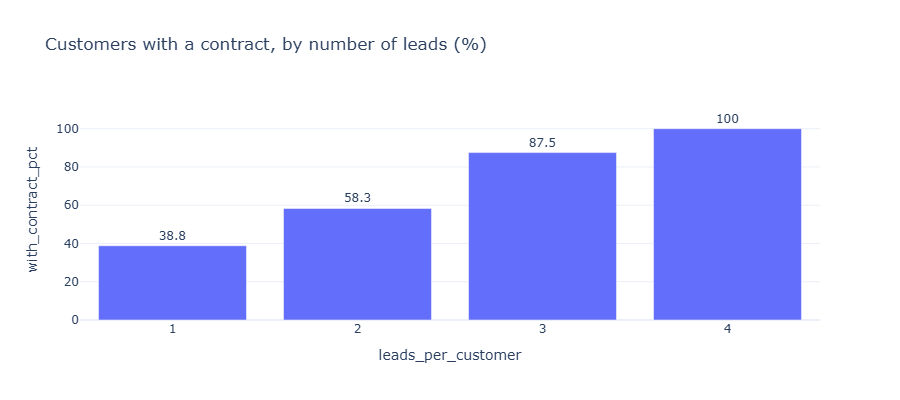

In [13]:
bar_chart(
    by_leads,
    x="leads_per_customer",
    y="with_contract_pct",
    title="Customers with a contract, by number of leads (%)",
)

**Reading:** customers with several leads hold a contract much more often: 38.8 % with one lead, 58.3 % with
two, 87.5 % with three (7 of 8). This does not prove that more leads cause more contracts (someone about to buy
may simply compare more, and each lead is another chance to sign), and the groups with several leads are small.
But repeat visitors are clearly the warmer audience for a follow-up.

### 8. Which customers bring the most active premium?

In [14]:
query("""
    select customer_email, leads, conversions, total_active_premium
    from mart_customers
    where has_active_contract
    order by total_active_premium desc nulls last, customer_email
    limit 10
""")

,customer_email,leads,conversions,total_active_premium
0,mia.berger@gmail.com,4,3,2043.92
1,leon.aigner@aon.at,3,2,1387.57
2,sophie.aigner@hotmail.com,3,1,1359.55
3,julia.brunner@hotmail.com,1,1,1299.57
4,paul.winkler@aon.at,1,1,1159.06
5,paul.aigner@gmail.com,1,1,999.13
6,hannah.fuchs@gmx.at,1,2,894.41
7,paul.fuchs@outlook.com,1,1,870.57
8,laura.gruber@outlook.com,3,1,856.97
9,lena.lang@outlook.com,1,1,821.9


**Reading:** mia.berger@gmail.com brings the most active premium (2,043.92 EUR from two active contracts, after
4 leads). hannah.fuchs@gmx.at (894.41 EUR) is only on the list because the customer view counts all contracts:
the lead of her active contract is unknown, so it is missing from the lead tables.